In this Notebook, we will do the following:

1. Select a portrait (creative commons)
2. Select a mosaic size and resolution
3. Select a colour
4. Select a background
5. Create a mosaic from the portrait
6. Add the background to the portrait

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
# Add the src/ directory to the path
# TODO: this is not a very clean and robust way of importing
sys.path.append(os.path.abspath("../src"))

import mosaics

from PIL import Image
import cellpylib as cpl

# Define your custom colors using hex codes
from matplotlib.colors import LinearSegmentedColormap
ugent_blue = '#1E64C8'  # dark blue
ugent_yellow = '#FFD200'  # warm yellow
ugent_black = '#000000'  # black
ugent_white = '#FFFFFF'  # white

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(np.float64(-0.5), np.float64(1413.5), np.float64(1999.5), np.float64(-0.5))

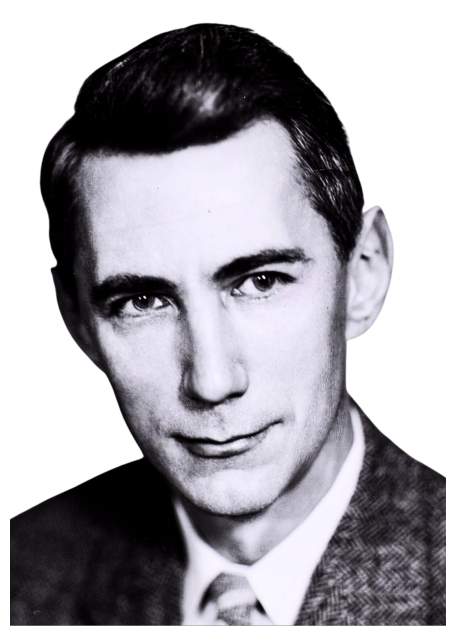

In [6]:
# Inspect Bram's artwork and its layers

image_name = "Claude"
extension = "png"
image_path = f"../input/bw26/portraits/{image_name}.{extension}"

img = Image.open(image_path)

fig, ax = plt.subplots(1,1,figsize=(8*np.sqrt(2), 8))

ax.imshow(img)
ax.axis('off')

In [ ]:
# Select mosaic dimensions

grid_size=150
level=4
invert=True
random=True
empty_tiles_cutoff=.99
horizontal_cropping = 0.0
bottom_cropping = 1.

SAVEARRAY = True

# Load the image and convert it to a still life mosaic
# find right image
solution_mosaic = mosaics.image_to_still_life(image_path,
                                            grid_size=grid_size,
                                            level=level,
                                            invert=invert,
                                            random=random,
                                            empty_tiles_cutoff=empty_tiles_cutoff)

# crop horizontally
if horizontal_cropping:
    crop_pixels = int(horizontal_cropping * solution_mosaic.shape[1] / 2)
    solution_mosaic = solution_mosaic[:, crop_pixels:-crop_pixels]

# crop bottom
if bottom_cropping<1:
    crop_pixels = int(bottom_cropping * solution_mosaic.shape[0])
    solution_mosaic = solution_mosaic[:-crop_pixels, :]

if SAVEARRAY:
    np.save(f'../output/bw26/arrays/{image_name}/{image_name}-mosaic-level{level}-gridsize{grid_size}.npy',
            solution_mosaic)

mosaic_shape = solution_mosaic.shape
print("\nMosaic shape:", mosaic_shape)
print("Shape denominators:", mosaics.list_denominators(mosaic_shape[1]))


Mosaic shape: (2568, 1815)
Shape denominators: [1, 3, 5, 11, 15, 33, 55, 121, 165, 363, 605, 1815]


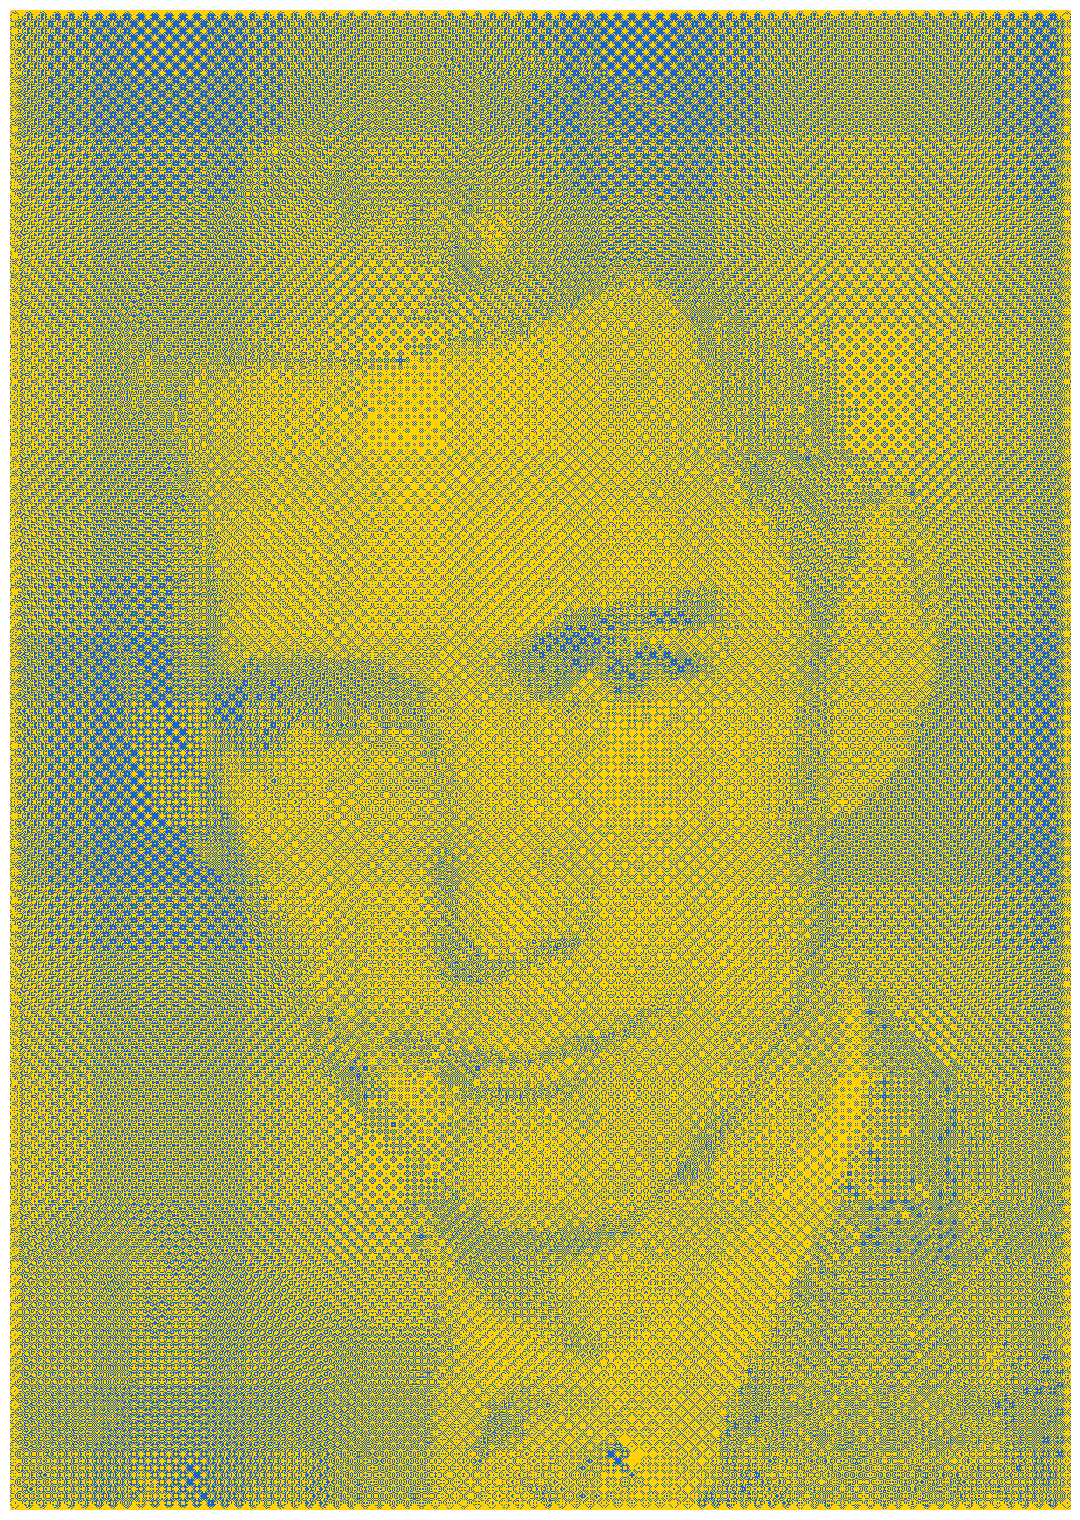

In [15]:
# Show and save results

INDEX = 4
SAVEFIG = True

fig, ax = plt.subplots(1, 1, figsize=(8*np.sqrt(2), 8))

# IMPORTANT: pick a size that is a denominator of the mosaic shape
fig_size = 15
fig.set_size_inches(fig_size, fig_size)
ax.axis('off')

# Create colormap with the selected colour
cmap_colors = [ugent_yellow, ugent_blue]
custom_cmap = LinearSegmentedColormap.from_list('custom', cmap_colors, N=2)

# show mosaic
ax.imshow(solution_mosaic, cmap=custom_cmap, interpolation='none')

# remove axes
ax.axis('off')
ax.axis('off')

# Remove padding
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

if SAVEFIG:
    dpi = solution_mosaic.shape[1] // fig_size
    plt.savefig(f'../output/bw26/images/{image_name}-mosaic-level{level}-gridsize{grid_size}.png',
                dpi=dpi, # 100 dpi × 10 inches = 1000 pixels
                bbox_inches='tight',
                pad_inches=0)
    # plt.close()